# Visualizando os resultados

In [146]:
import hvplot.xarray
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import numpy as np

In [1]:
from pathlib import Path
# IPATH = Path('./inputs_rev1/')
# OPATH = Path('./outputs_rev1/')

# IPATH = Path('./inputs_ressuspensao_bruno/')
# OPATH = Path('./outputs_ressuspensao_bruno/')

PATH_PATTERN = 'outputs_refuel/finalss/'
OPATH = Path('outputs_refuel')

In [2]:
####################### Abrir NetCDF com TSTEP (sem coluna time)
# ds = xr.open_mfdataset('inputs_rev1/netcdf_files/*.nc')
def preprocess(ds):
    # extrai a data base do nome do arquivo
    date_str = ds.encoding['source'].split('/')[-1].replace('.nc', '')
    base_date = pd.to_datetime(date_str)

    # garante que TSTEP é um array NumPy (e ordenado corretamente)
    tstep_vals = np.sort(ds['TSTEP'].values)

    # remove a 25ª hora, se existir (TSTEP=24)
    tstep_vals = tstep_vals[tstep_vals < 24]

    # cria o vetor de tempo real (datetime64)
    time = base_date + pd.to_timedelta(tstep_vals, unit='h')

    # substitui a coordenada TSTEP por time
    ds = ds.sel(TSTEP=tstep_vals)
    ds = ds.assign_coords(time=("TSTEP", time))
    ds = ds.swap_dims({'TSTEP': 'time'})

    return ds



In [78]:
tablePath = Path(
    os.path.join(
        os.path.dirname(os.path.dirname(os.getcwd())),
        'outputs',
        'emissoes_cidades',
        'emissoes_2023_01'
    )
)

In [ ]:
tablePath = Path(
    os.path.join(
        os.path.dirname(os.path.dirname(os.getcwd())),
        'outputs',
        'emissoes_brasil',
        'emissoes_2023'
    )
)

In [81]:
from pathlib import Path
import os
import pandas as pd

tablePath = Path(
    os.path.join(
        os.path.dirname(os.path.dirname(os.getcwd())),
        'outputs',
        'emissoes_cidades',
        'emissoes_2023_01'
    )
)

sorted_files = sorted(tablePath.rglob('*.parquet'))
# nomes dos arquivos
nomes_arquivos = [f.name for f in sorted_files]

# concatenação dos parquet
df = pd.concat(
    [pd.read_parquet(f) for f in sorted_files[:7]],
    ignore_index=True
)

In [92]:
a = df[df['city_id']== 1100015]

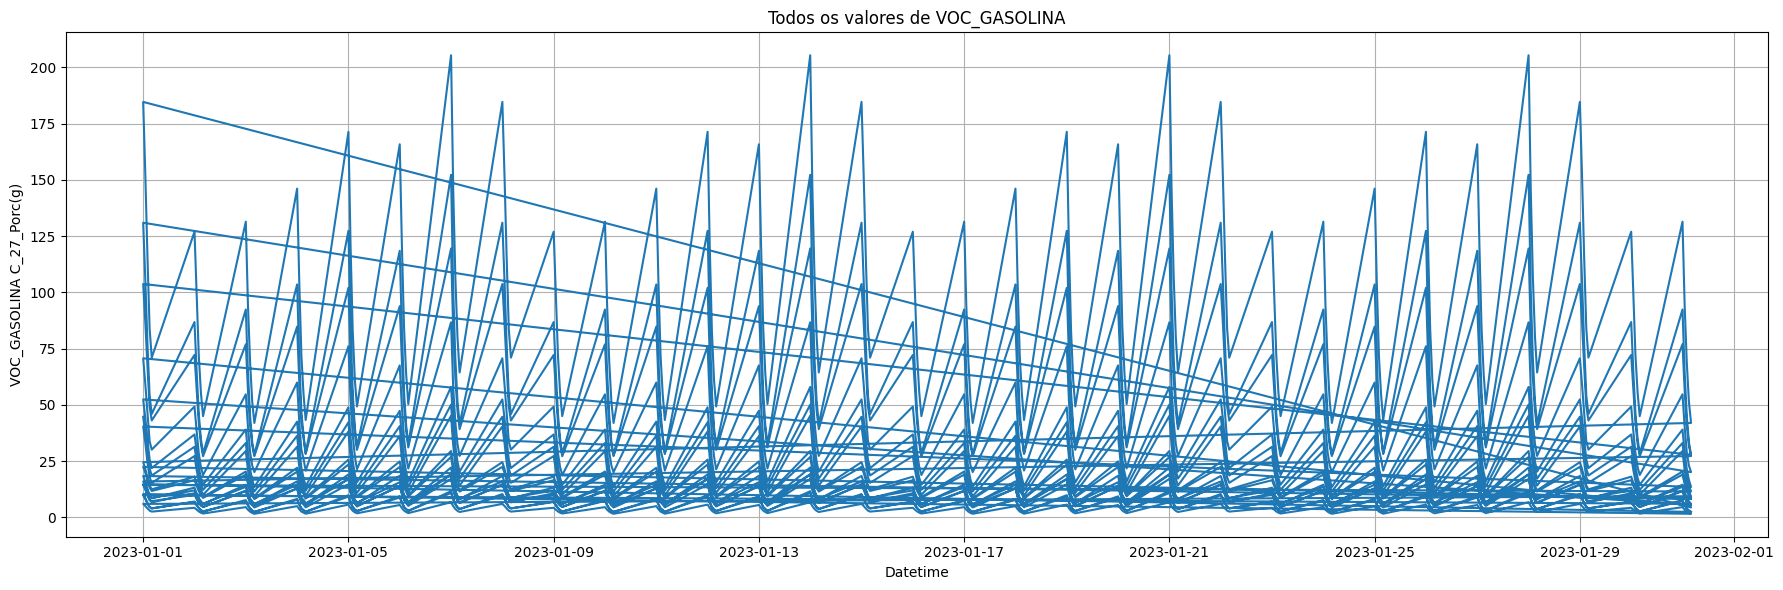

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# garantir datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# remover NaN
df_plot = df.dropna(subset=['VOC_GASOLINA C_27_Porc(g)'])

plt.figure(figsize=(18,6))

plt.plot(
    df_plot['datetime'],
    df_plot['VOC_GASOLINA C_27_Porc(g)'].values
)

plt.xlabel('Datetime')
plt.ylabel('VOC_GASOLINA C_27_Porc(g)')
plt.title('Todos os valores de VOC_GASOLINA')

plt.grid(True)
plt.tight_layout()

plt.show()

In [85]:
a = df.index.get_level_values('cell_id')[0]
df.xs(a, level='cell_id')

KeyError: 'Requested level (cell_id) does not match index name (None)'

In [51]:
from pathlib import Path
import os
import pandas as pd

tablePath = Path(
    os.path.join(
        os.path.dirname(os.path.dirname(os.getcwd())),
        'outputs',
        'emissoes_brasil',
        'emissoes_2023'
    )
)

sorted_files = sorted(tablePath.rglob('*.parquet'))
# nomes dos arquivos
nomes_arquivos = [f.name for f in sorted_files]

# concatenação dos parquet
df = pd.concat(
    [pd.read_parquet(f) for f in sorted_files]
)

In [57]:
a = df.index.get_level_values('cell_id')[0]

In [61]:
df_cell = df.xs(a, level='cell_id')

In [77]:
df_7dias['VOC_GASOLINA C_27_Porc(g)'].values

array([3.45644495, 2.86850117, 2.20729589, 1.59253882, 1.44239942,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 2.34171851,
       1.8052643 , 1.32020606, 1.03261859, 0.88210576, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 2.63152194, 1.93448876,
       1.36369047, 1.08975343, 0.9902665 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 2.8913355 , 1.98544001, 1.39775

In [4]:
import xarray as xr
import pandas as pd
import numpy as np

In [5]:
ds = xr.open_mfdataset(
    f'{PATH_PATTERN}/*.nc',
    combine='nested',
    concat_dim='time',
    preprocess=preprocess)



In [7]:
ds

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 168, y: 418, x: 391)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2023-03-01 ... 2023-03-07T23:00:00
  * y        (y) int64 3kB 1 2 3 4 5 6 7 8 9 ... 411 412 413 414 415 416 417 418
  * x        (x) int64 3kB 1 2 3 4 5 6 7 8 9 ... 384 385 386 387 388 389 390 391
    TSTEP    (time) int32 672B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
    lat      (y, x) float32 654kB dask.array<chunksize=(418, 391), meta=np.ndarray>
    lon      (y, x) float32 654kB dask.array<chunksize=(418, 391), meta=np.ndarray>
Data variables: (12/21)
    ACET     (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    ALD2     (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    ALDX     (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    APIN     (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    BENZ     (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    ETH      (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    ...       ...
    OLE      (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    PAR      (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    PRPA     (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    TOL      (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    UNR      (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    XYLMN    (time, y, x) float64 220MB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>

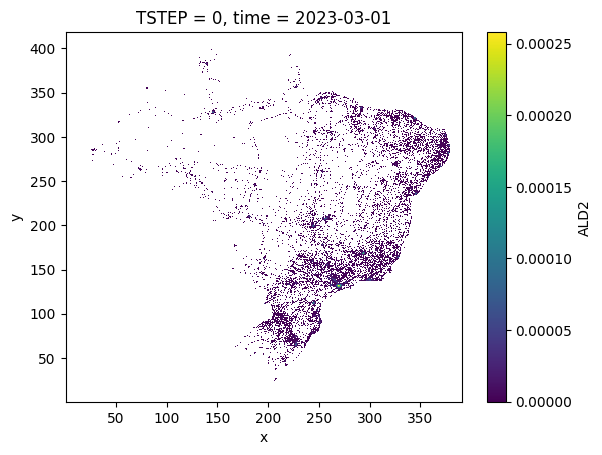

In [103]:
ds['ALD2'][0].plot()

In [97]:
ds['VOC_TOTAL_g'] = ( ds['VOC_GASOLINA C_27_Porc(g)'] + ds['VOC_AEHC_93_Porc(g)'])

KeyError: "No variable named 'VOC_GASOLINA C_27_Porc(g)'. Variables on the dataset include ['ACET', 'ALD2', 'ALDX', 'APIN', 'BENZ', ..., 'x', 'TSTEP', 'lat', 'lon', 'time']"

In [6]:
# ds[EMISSION].assign_coords(lat=(("y", "x"), ds.lat[::-1, :].data)).unify_chunks().hvplot.quadmesh(
#     x="lon", y="lat",
#     # groupby=["weekday", "hour"],  # sliders para navegar no tempo
#     rasterize=True,  # útil se o grid for grande
#     cmap="viridis",
#     frame_width=600,
#     frame_height=400)

In [7]:
# # Salvando como html interativo
# import holoviews as hv
# from holoviews import opts

# hv.extension("bokeh")  # ou "matplotlib", mas "bokeh" é mais interativo

# plot = ds[EMISSION] \
#     .assign_coords(lat=(("y", "x"), ds.lat[::-1, :].data)).hvplot(
#     x="lon", y="lat",
#     groupby="hour",
#     cmap="viridis",
#     rasterize=True
# )

# hv.save(plot, OPATH / "animacao.html")  # salva como HTML interativo

(array([1.058395e+06, 1.635000e+03, 5.330000e+02, 1.900000e+02,
        8.100000e+01, 3.500000e+01, 1.800000e+01, 5.000000e+00,
        3.000000e+00, 1.000000e+00]),
 array([0.        , 0.09670854, 0.19341708, 0.29012561, 0.38683415,
        0.48354269, 0.58025123, 0.67695977, 0.77366831, 0.87037684,
        0.96708538]),
 <BarContainer object of 10 artists>)

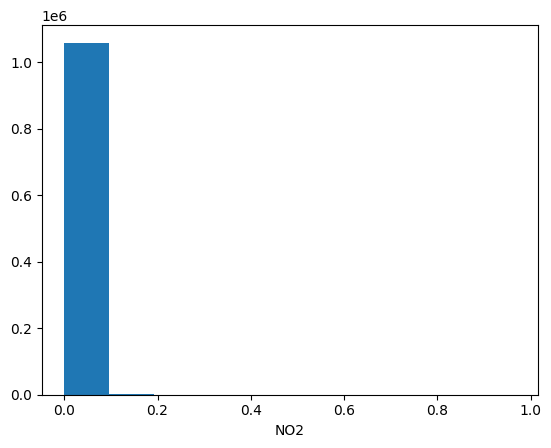

In [8]:
component = EMISSION

# Seleciona a variável de interesse
da = ds[component].assign_coords(
    lat=(("y", "x"), ds.lat[::-1, :].data)).unify_chunks().sortby('time')

da.plot.hist()

# Tentativa 1: Linear

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x761ffa146410>>
Traceback (most recent call last):
  File "/home/igorvrt/Área de Trabalho/BRAVES/4.Processos/.venv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1920x1440', '-pix_fmt', 'rgba', '-framerate', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', PosixPath('outputs_qualis/animacao.mp4')]' returned non-zero exit status 255.

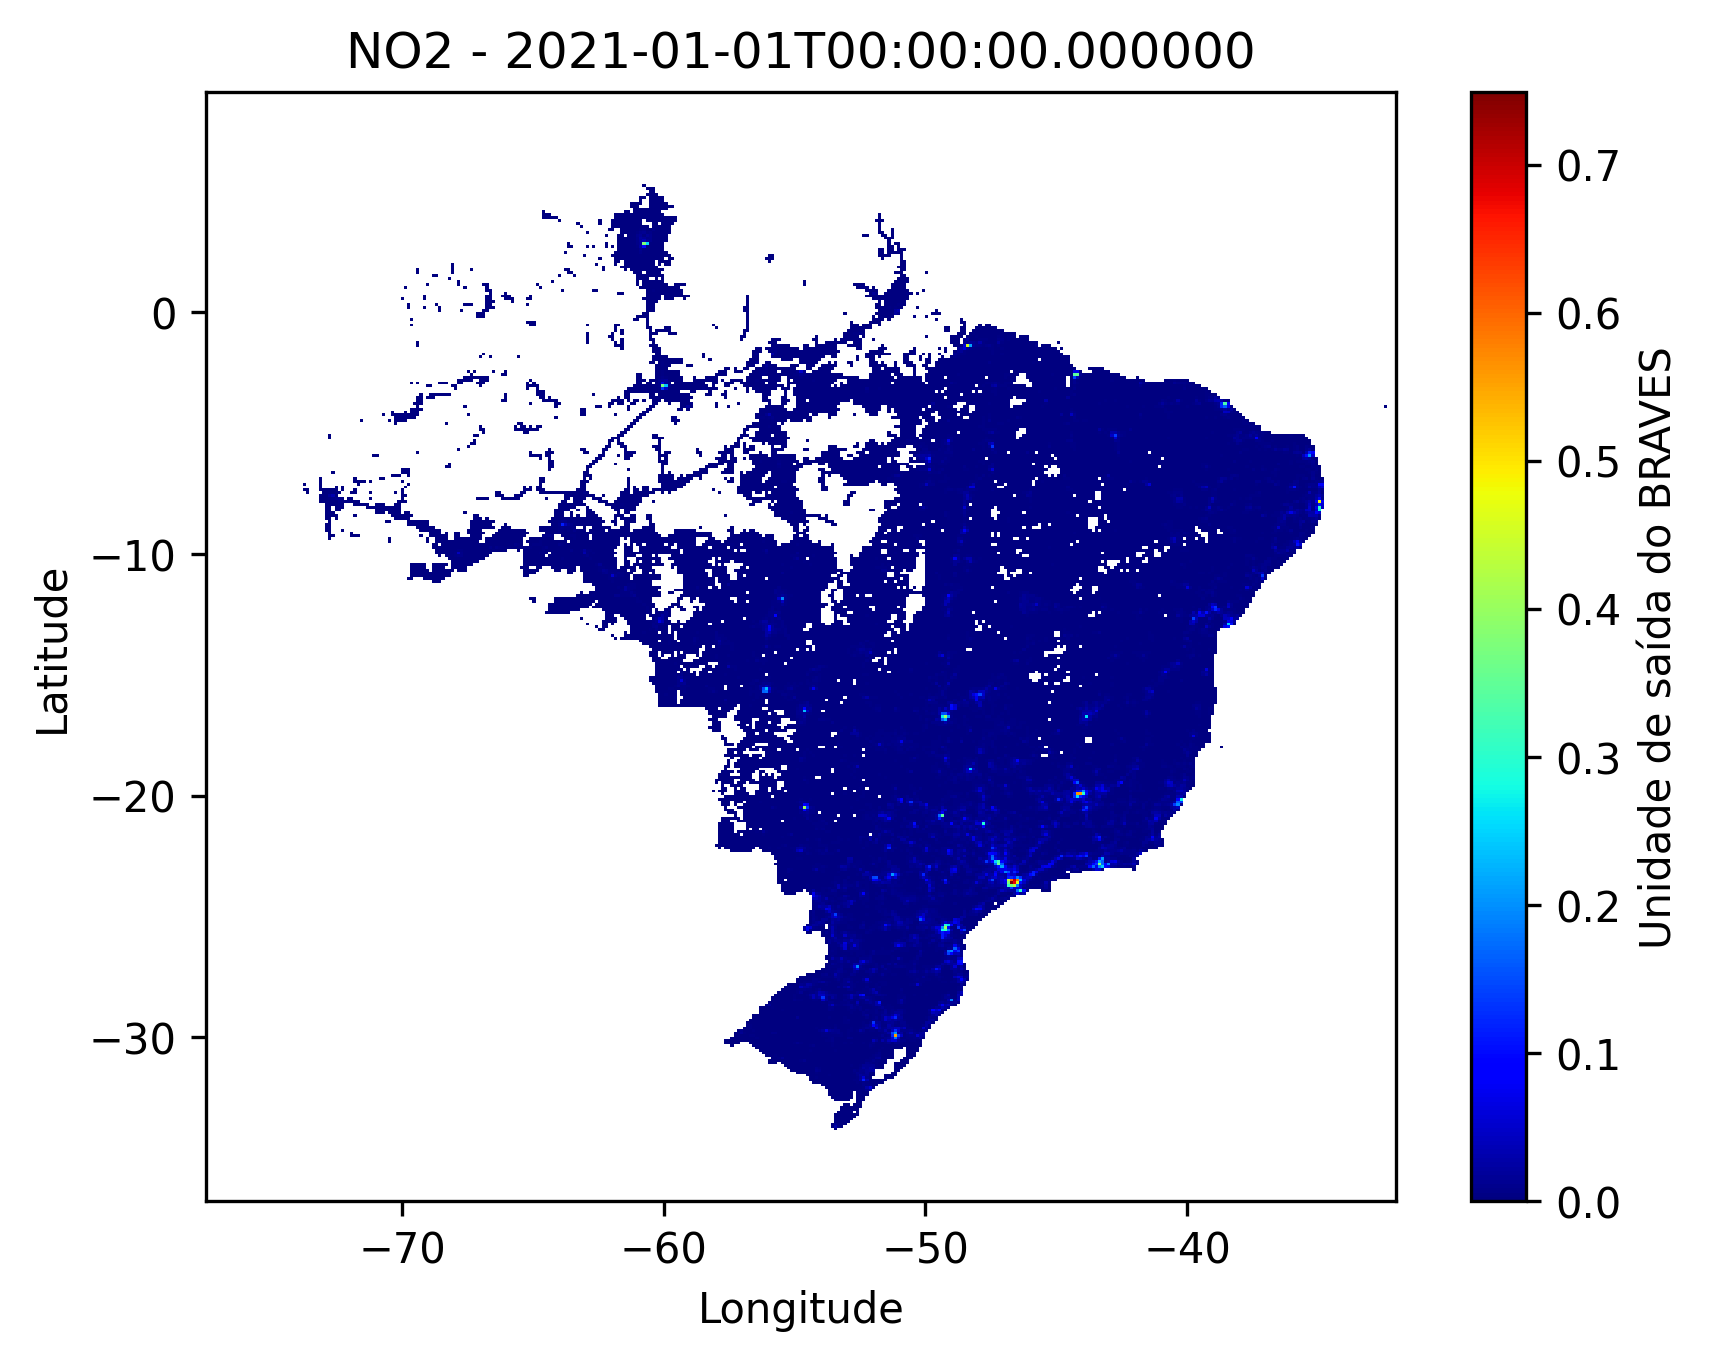

In [6]:
# # Salvando gif e mp4

# # weekdays_dict = {
# #     0: "Segunda-feira",
# #     1: "Terça-feira",
# #     2: "Quarta-feira",
# #     3: "Quinta-feira",
# #     4: "Sexta-feira",
# #     5: "Sábado",
# #     6: "Domingo"
# # }

# # Vamos empacotar weekday + hour em um eixo tempo
# # ds_time = ds.stack(time=("weekday", "hour"))

# component = EMISSION

# # Seleciona a variável de interesse
# da = ds[component].assign_coords(
#     lat=(("y", "x"), ds.lat[::-1, :].data)).unify_chunks().sortby('time')

# fig, ax = plt.subplots(dpi=300)

# # Primeira imagem
# im = ax.pcolormesh(da.lon, da.lat, da.isel(time=0), cmap="jet")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# plt.colorbar(im, ax=ax, label="Unidade de saída do BRAVES")

# # Função para atualizar cada frame
# def update(frame):
#     im.set_array(da.isel(time=frame).values.ravel())  # atualiza os dados
#     # weekday = int(da["weekday"].isel(time=frame).values)
#     # hour = int(da["hour"].isel(time=frame).values)
#     time = da["time"].isel(time=frame).values
#     ax.set_title(f"{component} - {time}")
#     return [im]

# # Cria animação
# ani = animation.FuncAnimation(
#     fig, update, frames=da.sizes["time"], blit=True)

# # Salvar em GIF
# # ani.save(OPATH / "animacao.gif", writer="pillow", fps=30)

# # Ou salvar em MP4 (precisa do ffmpeg instalado)
# ani.save(OPATH / "animacao.mp4", writer="ffmpeg", fps=10)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# from matplotlib import animation
# import cartopy.crs as ccrs

# cmap = "Spectral_r"
# component = EMISSION

# gdf = gpd.read_file('../../5.Vias_Contempladas_Tomtom_Brasil/inputs/mask/BR_Pais_2023.shp')

# # --- DataArray com lat invertida, como no seu gráfico ---
# da = ds[component].assign_coords(
#     lat=(("y", "x"), ds.lat[::-1, :].data)
# ).unify_chunks().sortby("time")

# # --- escala global fixa (fundamental para ficar igual ao gráfico) ---
# vmin = float(da.min().compute().item()) if hasattr(da.min(), "compute") else float(da.min().item())
# vmax = float(da.max().compute().item()) if hasattr(da.max(), "compute") else float(da.max().item())

# # --- Figura com Cartopy como no gráfico ---
# fig, ax = plt.subplots(
#     subplot_kw={"projection": ccrs.PlateCarree()},
#     figsize=(8, 6),
#     dpi=300
# )

# # Primeiro frame
# frame0 = da.isel(time=0).values

# mesh = ax.pcolormesh(
#     da.lon, da.lat, frame0,
#     cmap=cmap,
#     vmin=vmin, vmax=vmax,
#     shading="auto",
#     transform=ccrs.PlateCarree()
# )

# # Contorno do Brasil por cima (igual ao gráfico)
# gdf.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="black",
#     linewidth=0.6,
#     transform=ccrs.PlateCarree()
# )

# # --- limpa estética: sem título/labels/ticks/grid/spines ---
# ax.set_title("")
# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.set_xticks([])
# ax.set_yticks([])
# ax.grid(False)
# for spine in ax.spines.values():
#     spine.set_visible(False)

# # Extent igual ao seu padrão (ajuste se quiser “colar” no domínio do da)
# ax.set_extent([
#     float(da["lon"].min()), float(da["lon"].max()),
#     float(da["lat"].min()), float(da["lat"].max())
# ], crs=ccrs.PlateCarree())

# # Espaço inferior para a colorbar pequena
# fig.subplots_adjust(bottom=0.10)

# # --- Colorbar manual centralizada, pequena e horizontal ---
# bar_width = 0.2
# bar_height = 0.01
# bar_x = 0.5 - bar_width / 2
# bar_y = 0.05
# cax = fig.add_axes([bar_x, bar_y, bar_width, bar_height])

# ticks = np.linspace(vmin, vmax, 3)
# cb = fig.colorbar(
#     mesh,
#     cax=cax,
#     orientation="horizontal",
#     ticks=ticks,
#     format=mticker.FormatStrFormatter("%.0e")
# )
# cb.set_label("Unidade de saída do BRAVES", labelpad=5)
# cb.ax.xaxis.set_label_position("top")

# # --- Atualização por frame ---
# def update(frame):
#     z = da.isel(time=frame).values
#     mesh.set_array(z.ravel())  # atualiza os dados

#     # se você tiver NaNs variáveis e quiser garantir escala:
#     mesh.set_clim(vmin, vmax)

#     # se você quiser um título (no gráfico estático você removeu; aqui deixo opcional)
#     time = da["time"].isel(time=frame).values
#     ax.set_title(f"{component} - {time}")

#     return (mesh,)

# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=da.sizes["time"],
#     blit=True
# )

# ani.save(OPATH / "animacao.mp4", writer="ffmpeg", fps=10)
# # ani.save(OPATH / "animacao.gif", writer="pillow", fps=30)

# Tentativa 2: Lognorm

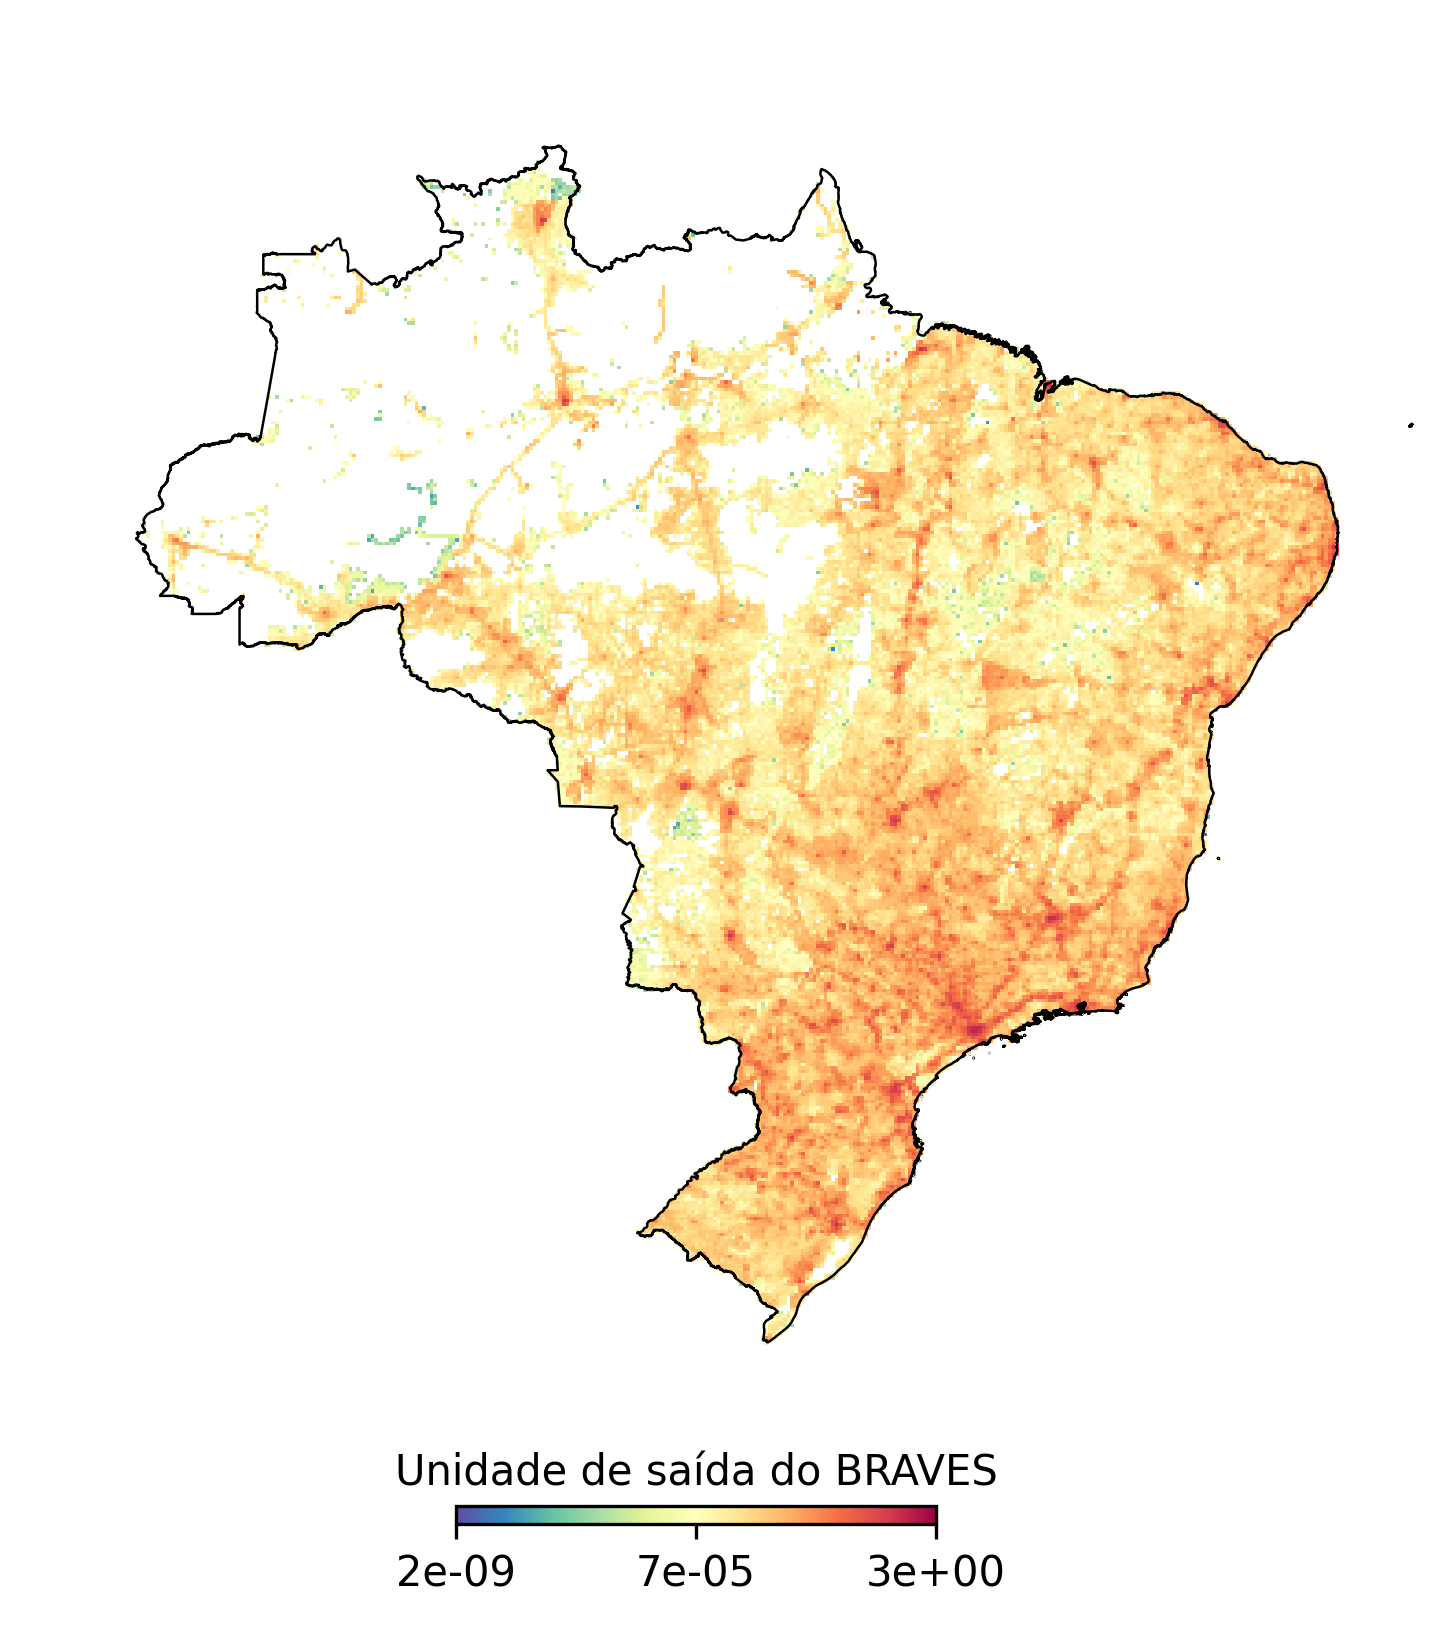

In [15]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# from matplotlib import animation
# from matplotlib.colors import LogNorm
# import geopandas as gpd
# import cartopy.crs as ccrs

# cmap = "Spectral_r"
# component = EMISSION

# gdf = gpd.read_file('../../5.Vias_Contempladas_Tomtom_Brasil/inputs/mask/BR_Pais_2023.shp')

# # --- DataArray com lat invertida, como no seu gráfico ---
# da = ds[component].assign_coords(
#     lat=(("y", "x"), ds.lat[::-1, :].data)
# ).unify_chunks().sortby("time")

# # LOG
# positive = da.where(da > 0)

# vmin = float(positive.min().compute())
# vmax = float(positive.max().compute())

# # LOG
# norm = LogNorm(vmin=vmin, vmax=vmax)

# # --- Figura com Cartopy como no gráfico ---
# fig, ax = plt.subplots(
#     subplot_kw={"projection": ccrs.PlateCarree()},
#     figsize=(8, 6),
#     dpi=300
# )

# # Primeiro frame
# frame0 = da.isel(time=0).values

# mesh = ax.pcolormesh(
#     da.lon, da.lat, frame0,
#     cmap=cmap,
#     # vmin=vmin, vmax=vmax,
#     norm=norm,
#     shading="auto",
#     transform=ccrs.PlateCarree()
# )

# # Contorno do Brasil por cima (igual ao gráfico)
# # gdf.plot(
# #     ax=ax,
# #     facecolor="none",
# #     edgecolor="black",
# #     linewidth=0.6,
# #     transform=ccrs.PlateCarree()
# # )

# ax.add_geometries(
#     gdf.geometry,
#     crs=ccrs.PlateCarree(),      # CRS das geometrias (lon/lat)
#     facecolor="none",
#     edgecolor="black",
#     linewidth=0.6
# )

# # --- limpa estética: sem título/labels/ticks/grid/spines ---
# ax.set_title("")
# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.set_xticks([])
# ax.set_yticks([])
# ax.grid(False)
# for spine in ax.spines.values():
#     spine.set_visible(False)

# # Extent igual ao seu padrão (ajuste se quiser “colar” no domínio do da)
# ax.set_extent([
#     float(da["lon"].min()), float(da["lon"].max()),
#     float(da["lat"].min()), float(da["lat"].max())
# ], crs=ccrs.PlateCarree())

# # Espaço inferior para a colorbar pequena
# fig.subplots_adjust(bottom=0.10)

# # --- Colorbar manual centralizada, pequena e horizontal ---
# bar_width = 0.2
# bar_height = 0.01
# bar_x = 0.5 - bar_width / 2
# bar_y = 0.05
# cax = fig.add_axes([bar_x, bar_y, bar_width, bar_height])

# # LOG
# ticks = np.logspace(
#     np.log10(vmin),
#     np.log10(vmax),
#     3
# )

# # ticks = np.linspace(vmin, vmax, 3)

# cb = fig.colorbar(
#     mesh,
#     cax=cax,
#     orientation="horizontal",
#     ticks=ticks,
#     format=mticker.FormatStrFormatter("%.0e")
# )
# cb.set_label("Unidade de saída do BRAVES", labelpad=5)
# cb.ax.xaxis.set_label_position("top")

# # --- Atualização por frame ---
# def update(frame):
#     z = da.isel(time=frame).values
#     mesh.set_array(z.ravel())  # atualiza os dados

#     # se você tiver NaNs variáveis e quiser garantir escala:
#     # mesh.set_clim(vmin, vmax)

#     # se você quiser um título (no gráfico estático você removeu; aqui deixo opcional)
#     time = da["time"].isel(time=frame).values
#     ax.set_title(f"{component} - {time}")

#     return (mesh,)

# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=da.sizes["time"],
#     blit=True
# )

# ani.save(OPATH / "animacao_4.mp4", writer="ffmpeg", fps=10)
# # ani.save(OPATH / "animacao.gif", writer="pillow", fps=30)

# Tentativa 3: Power Norm

In [4]:
os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'inputs','BR_Regioes_2025','BR_Regioes_2025.shp')

'/home/artaxo/Notebooks/marcos.perrude/emiEvaporatives/outputs/emissoes_brasil/emissoes_2023'

In [26]:
ds

<xarray.Dataset> Size: 57GB
Dimensions:                    (time: 8760, y: 418, x: 391)
Coordinates:
  * time                       (time) datetime64[ns] 70kB 2023-01-01 ... 2023...
  * y                          (y) int64 3kB 1 2 3 4 5 6 ... 414 415 416 417 418
  * x                          (x) int64 3kB 1 2 3 4 5 6 ... 387 388 389 390 391
    TSTEP                      (time) int32 35kB 0 1 2 3 4 5 ... 19 20 21 22 23
    lat                        (y, x) float32 654kB dask.array<chunksize=(418, 391), meta=np.ndarray>
    lon                        (y, x) float32 654kB dask.array<chunksize=(418, 391), meta=np.ndarray>
Data variables:
    VOC_GASOLINA C_27_Porc(g)  (time, y, x) float64 11GB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    VOC_GASOLINA C_27_Porc(L)  (time, y, x) float64 11GB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    VOC_AEHC_93_Porc(g)        (time, y, x) float64 11GB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    VOC_AEHC_93_Porc(L)        (time, y, x) float64 11GB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>
    VOC_TOTAL_g                (time, y, x) float64 11GB dask.array<chunksize=(12, 209, 196), meta=np.ndarray>

In [33]:
da = ds['VOC_TOTAL_g'].assign_coords(
    lat=(("y", "x"), ds.lat[:, :].data)
).unify_chunks().sortby("time")

da.var

<bound method DataArrayAggregations.var of <xarray.DataArray 'VOC_TOTAL_g' (time: 8760, y: 418, x: 391)> Size: 11GB
dask.array<getitem, shape=(8760, 418, 391), dtype=float64, chunksize=(12, 209, 196), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * y        (y) int64 3kB 1 2 3 4 5 6 7 8 9 ... 411 412 413 414 415 416 417 418
  * x        (x) int64 3kB 1 2 3 4 5 6 7 8 9 ... 384 385 386 387 388 389 390 391
    TSTEP    (time) int32 35kB 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
    lat      (y, x) float32 654kB dask.array<chunksize=(209, 196), meta=np.ndarray>
    lon      (y, x) float32 654kB dask.array<chunksize=(209, 196), meta=np.ndarray>>

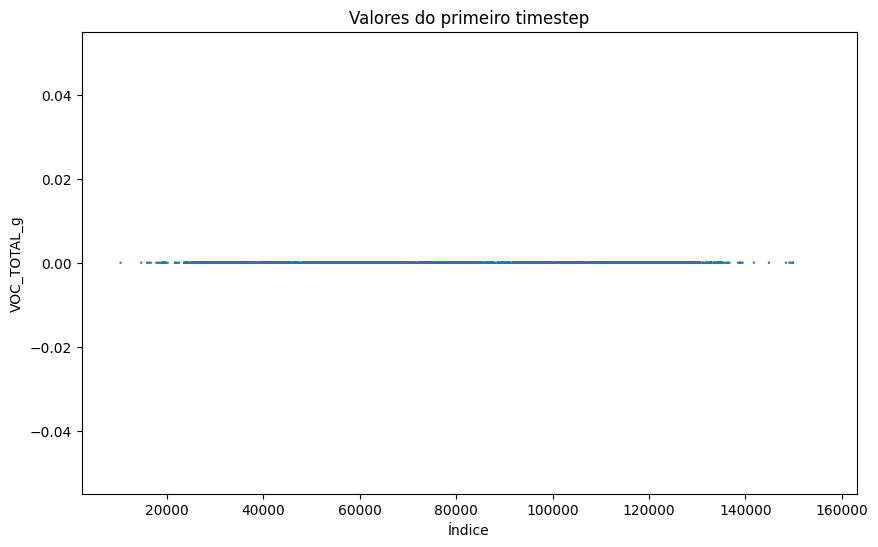

In [55]:
plt.figure(figsize=(10,6))

plt.plot(ds['VOC_GASOLINA C_27_Porc(g)'][12].values.flatten())

plt.xlabel('Índice')
plt.ylabel('VOC_TOTAL_g')
plt.title('Valores do primeiro timestep')

plt.show()

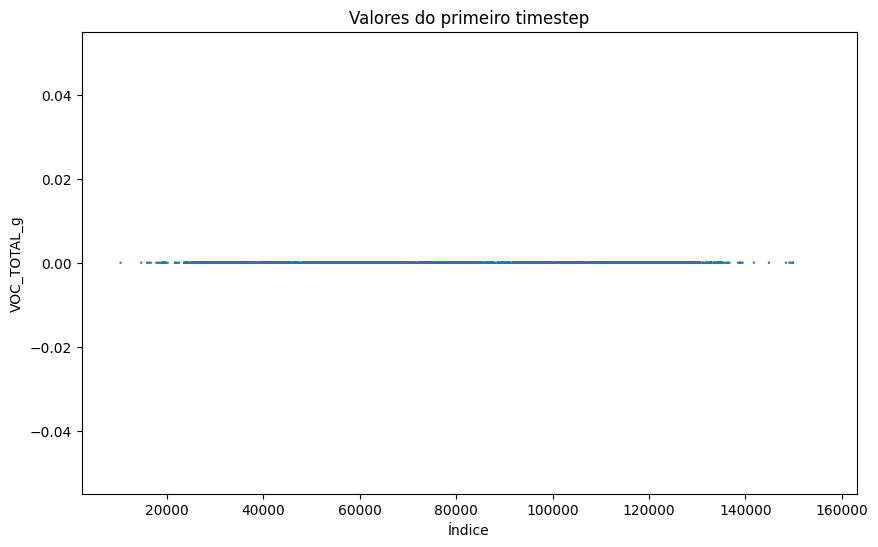

In [48]:
plt.figure(figsize=(10,6))

plt.plot(da[12].values.flatten())

plt.xlabel('Índice')
plt.ylabel('VOC_TOTAL_g')
plt.title('Valores do primeiro timestep')

plt.show()

In [110]:
da

<xarray.DataArray 'ALD2' (time: 168, y: 418, x: 391)> Size: 220MB
dask.array<getitem, shape=(168, 418, 391), dtype=float64, chunksize=(12, 209, 196), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2023-03-01 ... 2023-03-07T23:00:00
  * y        (y) int64 3kB 1 2 3 4 5 6 7 8 9 ... 411 412 413 414 415 416 417 418
  * x        (x) int64 3kB 1 2 3 4 5 6 7 8 9 ... 384 385 386 387 388 389 390 391
    TSTEP    (time) int32 672B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
    lat      (y, x) float32 654kB dask.array<chunksize=(209, 196), meta=np.ndarray>
    lon      (y, x) float32 654kB dask.array<chunksize=(209, 196), meta=np.ndarray>

In [113]:
da

<xarray.DataArray 'ALD2' (time: 168, y: 418, x: 391)> Size: 220MB
dask.array<getitem, shape=(168, 418, 391), dtype=float64, chunksize=(12, 209, 196), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2023-03-01 ... 2023-03-07T23:00:00
  * y        (y) int64 3kB 1 2 3 4 5 6 7 8 9 ... 411 412 413 414 415 416 417 418
  * x        (x) int64 3kB 1 2 3 4 5 6 7 8 9 ... 384 385 386 387 388 389 390 391
    TSTEP    (time) int32 672B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
    lat      (y, x) float32 654kB dask.array<chunksize=(209, 196), meta=np.ndarray>
    lon      (y, x) float32 654kB dask.array<chunksize=(209, 196), meta=np.ndarray>

In [8]:
da = ds['ALD2'].assign_coords(
    lat=(("y", "x"), ds.lat[:, :].data)
).unify_chunks().sortby("time")

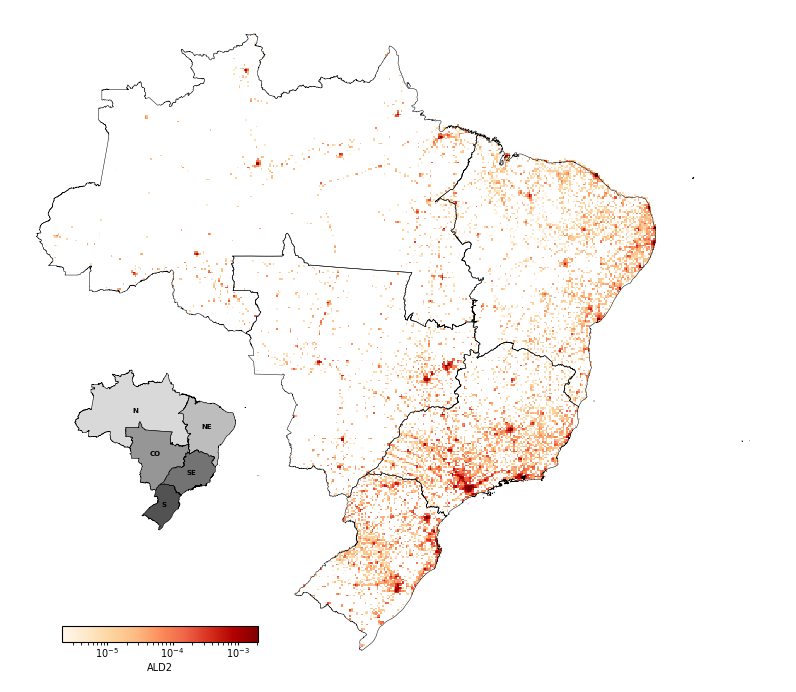

In [18]:
import pandas as pd
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
import rioxarray
cores = ["#d9d9d9", "#bdbdbd", "#969696", "#737373", "#525252"]
# =========================
# Dados
# =========================
gdf = gpd.read_file(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'inputs','BR_Regioes_2025','BR_Regioes_2025.shp'))
component = 'ALD2'
cmap = "OrRd"

# primeira semana
da_semana = da.isel(time=slice(0, 168))

# soma temporal
da_sum = da_semana.sum(dim='time')

# remover zeros
emissao_total = xr.where(da_sum > 0, da_sum, np.nan)


# =========================
# Figura principal
# =========================

fig = plt.figure(figsize=(14, 8))

# -------------------------
# Mapa principal
# -------------------------

ax1 = fig.add_axes([0.08, 0.08, 0.84, 0.84])

img = emissao_total.plot(
    ax=ax1,
    x='lon',
    y='lat',
    cmap=cmap,
    norm=colors.LogNorm(
        vmin=float(np.nanpercentile(emissao_total.values, 1)),
        vmax=float(np.nanpercentile(emissao_total.values, 99.8))
    ),
    add_colorbar=False
)

gdf.boundary.plot(
    ax=ax1,
    color="black",
    linewidth=0.35
)

ax1.set_axis_off()
ax1.set_aspect("equal")

# -------------------------
# Colorbar
# -------------------------

cax = fig.add_axes([0.26, 0.13, 0.14, 0.02])

cb = plt.colorbar(
    img,
    cax=cax,
    orientation="horizontal"
)

cb.ax.tick_params(
    labelsize=7,
    length=2,
    pad=1
)

cb.set_label(
    f'{component}',
    fontsize=7,
    labelpad=2)


ax2 = fig.add_axes([0.225, 0.26, 0.22, 0.22])

gdf.plot(
    ax=ax2,
    color=cores,
    edgecolor="black",
    linewidth=0.4
)

for idx, row in gdf.iterrows():

    x = row.geometry.centroid.x
    y = row.geometry.centroid.y

    ax2.text(
        x,
        y,
        row["SIGLA_RG"],
        fontsize=5,
        fontweight="bold",
        ha="center",
        va="center",
        color="black"
    )

ax2.set_axis_off()
ax2.set_aspect("equal")

# =========================
# Série/regional
# =========================


# =========================
# Salvar
# =========================

plt.show()

fig.savefig(
    f"{OPATH}/emissao_TOTAL_{component}_primeira_semana.png",
    dpi=500,
    bbox_inches="tight"
)

AttributeError: Rectangle.set() got an unexpected keyword argument 'cmap'

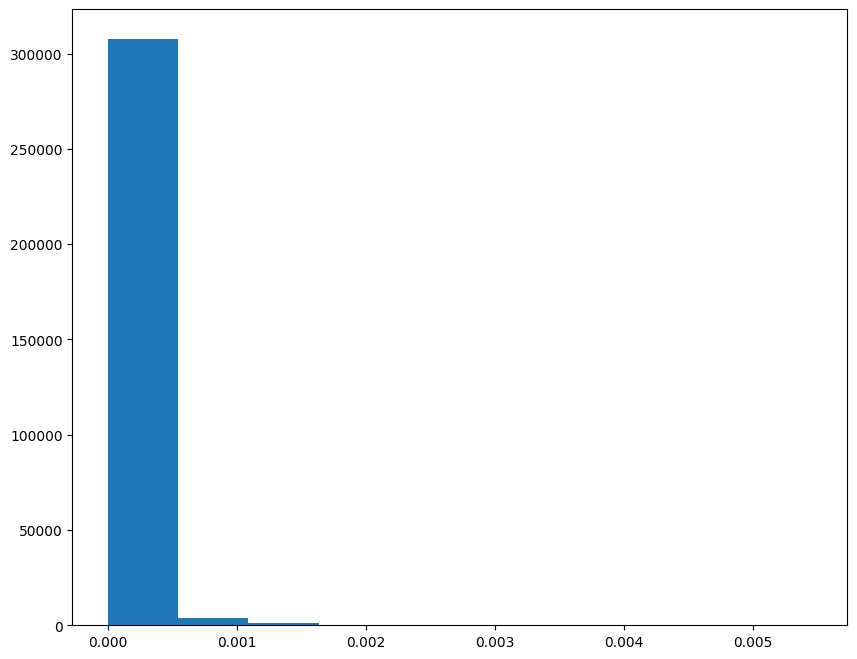

In [112]:
da = (
    ds[component]
    .assign_coords(lat=(("y", "x"), ds.lat.data))
    .unify_chunks()
    .sortby("time")
)

# soma temporal
da_sum = da.sum(dim='time')
da_sum = da_sum.where(da > 0)
# plot
fig, ax = plt.subplots(figsize=(10,8))

pcm = da_sum.plot(
    ax=ax,
    cmap="OrRd",
    add_colorbar=True
)

gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.5
)

ax.set_title(f'{component} - Soma da Primeira Semana')

plt.tight_layout()
plt.show()

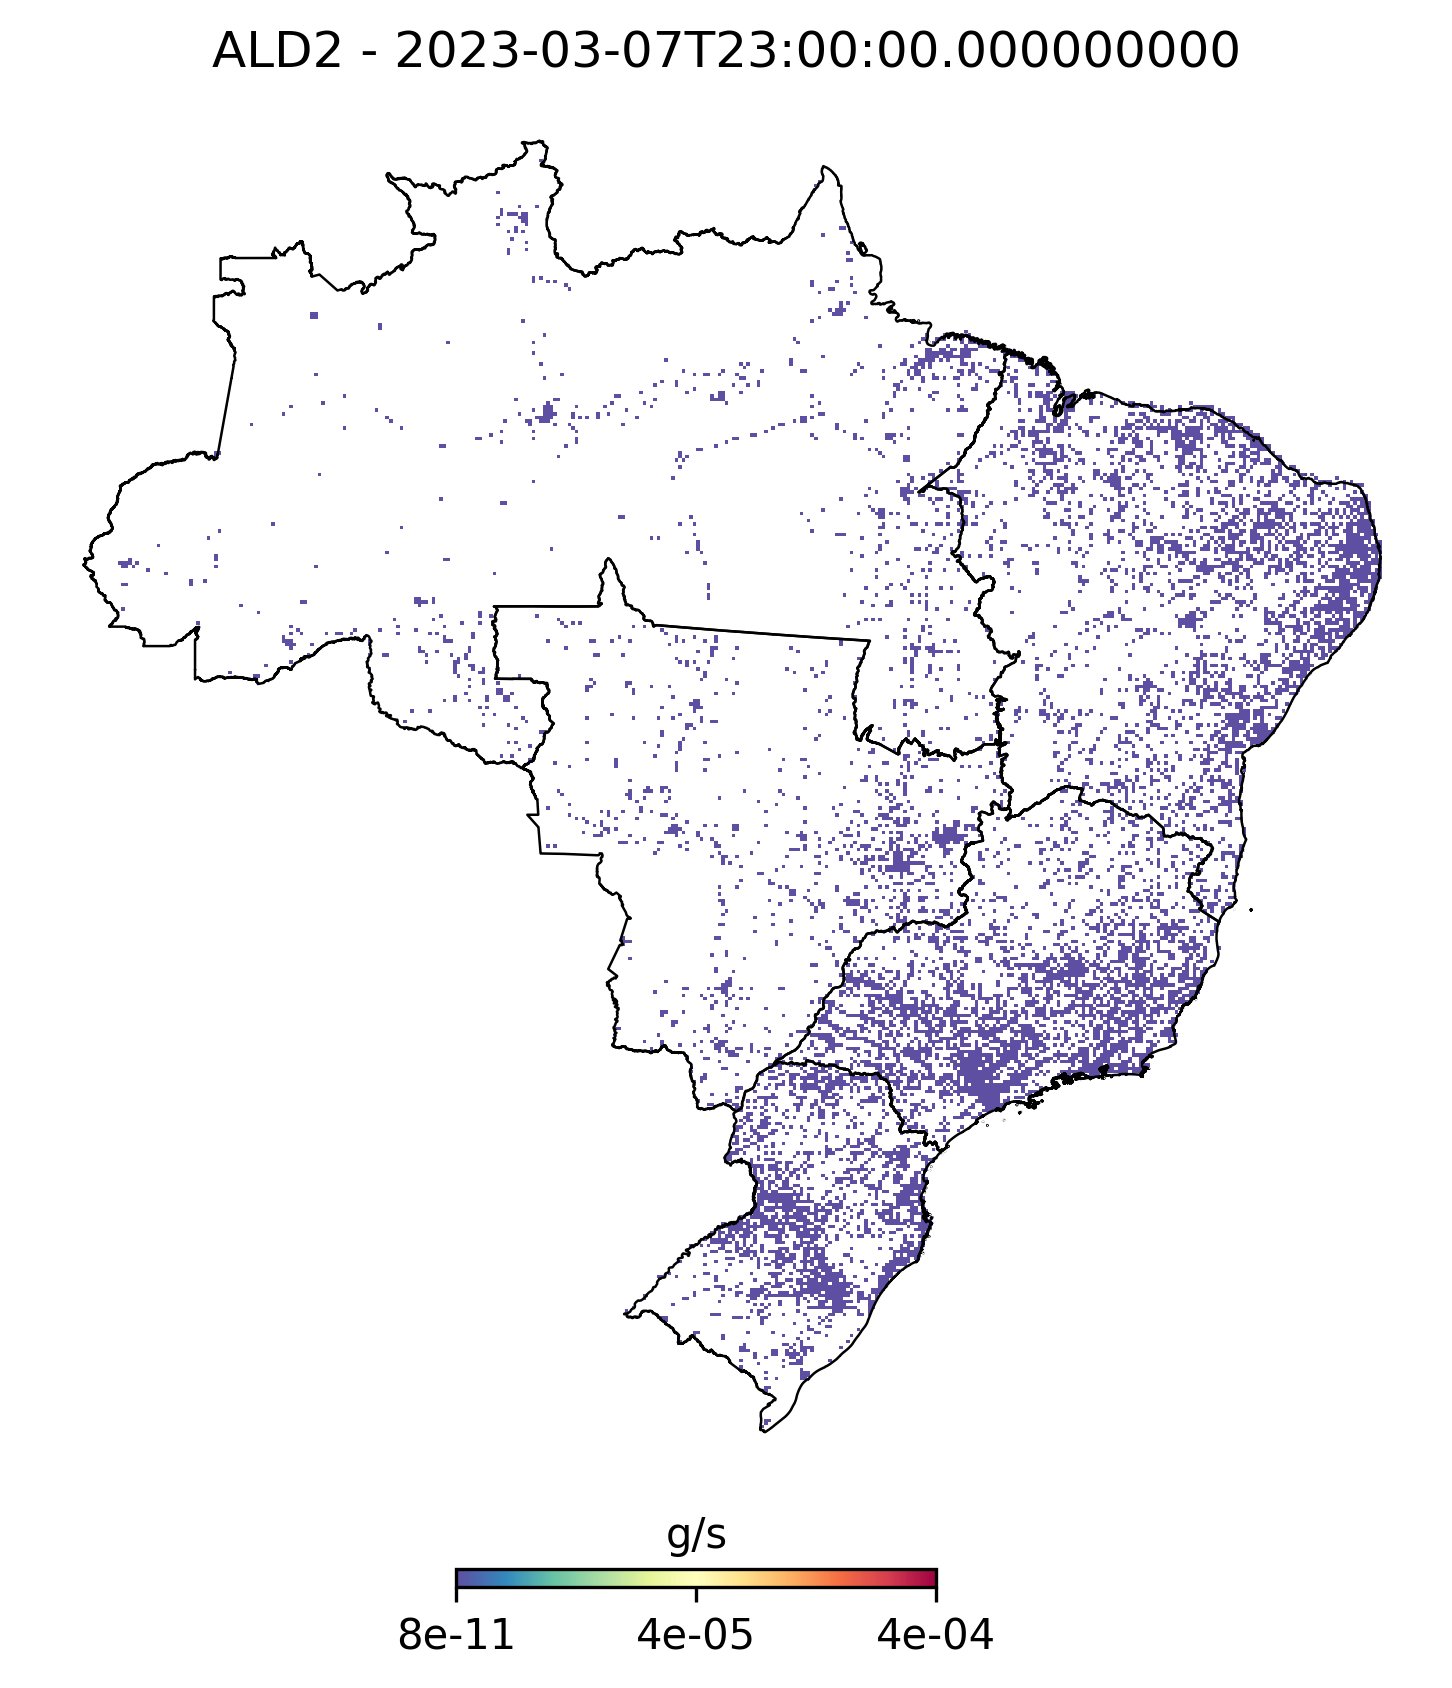

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import animation
from matplotlib.colors import PowerNorm
import geopandas as gpd
import cartopy.crs as ccrs

cmap = "Spectral_r"
component = 'ALD2'

gdf = gpd.read_file(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())),'inputs','BR_Regioes_2025','BR_Regioes_2025.shp'))

# --- DataArray com lat invertida, como no seu gráfico ---
da = ds[component].assign_coords(
    lat=(("y", "x"), ds.lat[:, :].data)
).unify_chunks().sortby("time")


# LOG
positive = da.where(da > 0)

vmin = float(positive.min().compute())
vmax = float(positive.max().compute())

eps = 1e-12

# LOG
norm = PowerNorm(gamma=0.30, vmin=max(vmin, eps), vmax=vmax)

# --- Figura com Cartopy como no gráfico ---
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(8, 6),
    dpi=300
)

# Primeiro frame
frame0 = da.isel(time=0).values

mesh = ax.pcolormesh(
    da.lon, da.lat, frame0,
    cmap=cmap,
    # vmin=vmin, vmax=vmax,
    norm=norm,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Contorno do Brasil por cima (igual ao gráfico)
# gdf.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="black",
#     linewidth=0.6,
#     transform=ccrs.PlateCarree()
# )

ax.add_geometries(
    gdf.geometry,
    crs=ccrs.PlateCarree(),      # CRS das geometrias (lon/lat)
    facecolor="none",
    edgecolor="black",
    linewidth=0.6
)

# --- limpa estética: sem título/labels/ticks/grid/spines ---
ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Extent igual ao seu padrão (ajuste se quiser “colar” no domínio do da)
ax.set_extent([
    float(da["lon"].min()), float(da["lon"].max()),
    float(da["lat"].min()), float(da["lat"].max())
], crs=ccrs.PlateCarree())

# Espaço inferior para a colorbar pequena
fig.subplots_adjust(bottom=0.10)

# --- Colorbar manual centralizada, pequena e horizontal ---
bar_width = 0.2
bar_height = 0.01
bar_x = 0.5 - bar_width / 2
bar_y = 0.05
cax = fig.add_axes([bar_x, bar_y, bar_width, bar_height])

# ticks = np.percentile(frame0[np.isfinite(frame0)], [5, 50, 95])
# ticks = np.linspace(vmin, vmax, 3)

mid = float(norm.inverse(0.5))
ticks = [norm.vmin, mid, norm.vmax]

cb = fig.colorbar(
    mesh,
    cax=cax,
    orientation="horizontal",
    ticks=ticks,
    format=mticker.FormatStrFormatter("%.0e")
)
cb.set_label("g/s", labelpad=5)
cb.ax.xaxis.set_label_position("top")

# --- Atualização por frame ---
def update(frame):
    z = da.isel(time=frame).values
    mesh.set_array(z.ravel())  # atualiza os dados

    # se você tiver NaNs variáveis e quiser garantir escala:
    # mesh.set_clim(vmin, vmax)

    # se você quiser um título (no gráfico estático você removeu; aqui deixo opcional)
    time = da["time"].isel(time=frame).values
    ax.set_title(f"{component} - {time}")

    return (mesh,)

ani = animation.FuncAnimation(
    fig,
    update,
    frames=da.sizes["time"],
    blit=True
)

ani.save(OPATH / "animacao_4.mp4", writer="ffmpeg", fps=10)
ani.save(OPATH / "animacao.gif", writer="pillow", fps=30)